# Option Payoff Graphs

This notebook implements basic option payoff diagrams.

The goal is to understand the difference between:

- payoff at maturity
- profit after premium
- long and short positions
- linear and non-linear payoff structures

We start with simple European call and put options.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## 1. Define the Underlying Price Range

We do not need real market data for payoff diagrams.

The payoff of an option depends on the price of the underlying at maturity, denoted as:

S(T)

We create a range of possible future prices.

In [ ]:
# Possible future prices of the underlying asset
S_T = np.linspace(100, 260, 300)

# Example strike price and premium
K = 180
call_premium = 12
put_premium = 10

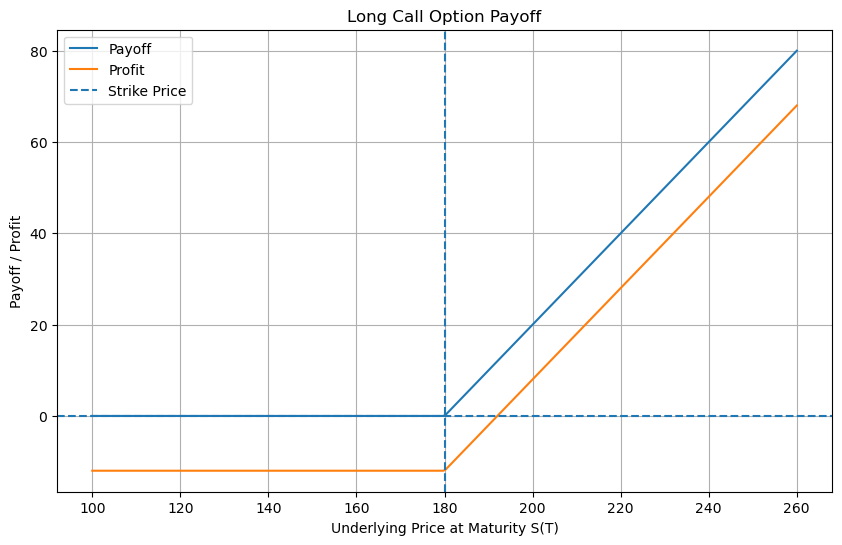

In [5]:
long_call_payoff = np.maximum(S_T - K, 0)
long_call_profit = long_call_payoff - call_premium
plt.figure(figsize=(10, 6))
plt.plot(S_T, long_call_payoff, label="Payoff")
plt.plot(S_T, long_call_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Long Call Option Payoff")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

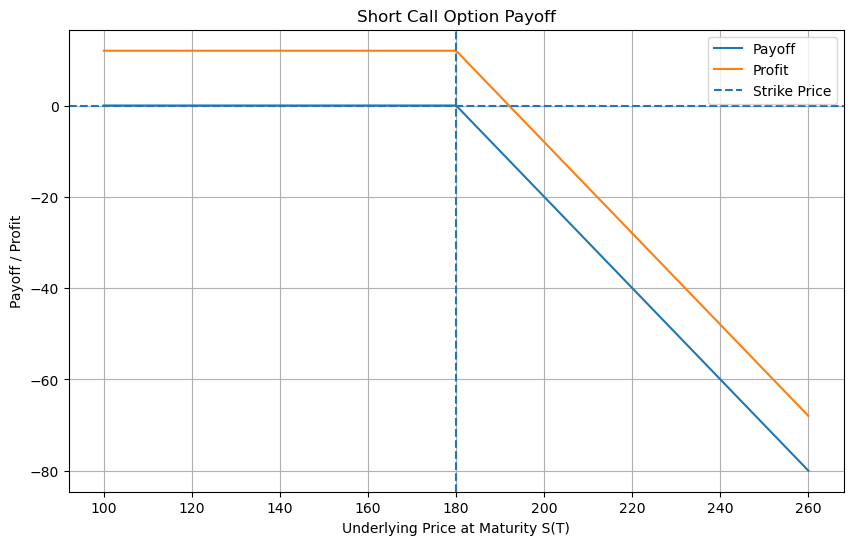

In [12]:
short_call_payoff = -np.maximum(S_T - K, 0)
short_call_profit = short_call_payoff + call_premium
plt.figure(figsize=(10, 6))
plt.plot(S_T, short_call_payoff, label="Payoff")
plt.plot(S_T, short_call_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Short Call Option Payoff")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

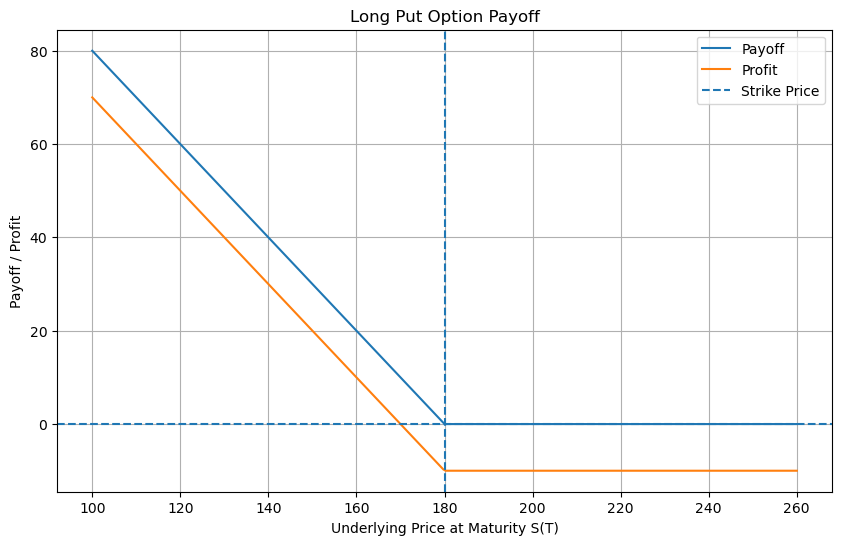

In [6]:
long_put_payoff = np.maximum(K - S_T, 0)
long_put_profit = long_put_payoff - put_premium
plt.figure(figsize=(10, 6))
plt.plot(S_T, long_put_payoff, label="Payoff")
plt.plot(S_T, long_put_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Long Put Option Payoff")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

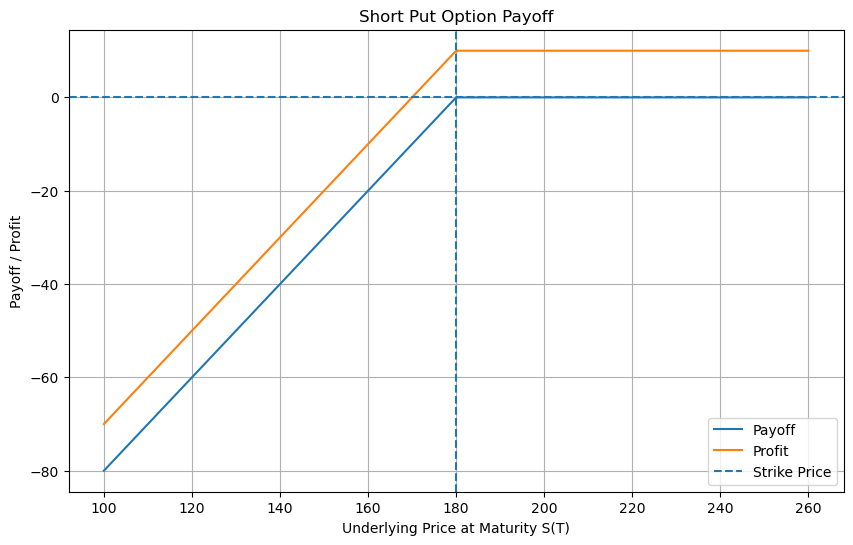

In [14]:
short_put_payoff = -np.maximum(K - S_T, 0)
short_put_profit = short_put_payoff + put_premium
plt.figure(figsize=(10, 6))
plt.plot(S_T, short_put_payoff, label="Payoff")
plt.plot(S_T, short_put_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Short Put Option Payoff")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

# Option Combinations

In this section, we combine basic call and put options to create more complex payoff profiles.

## Bull Spread Using Calls

A bull spread is used when we expect the underlying price to increase.

It can be built by:

- buying a call with lower strike K1
- selling a call with higher strike K2

where K1 < K2.

The strategy has limited loss and limited profit.

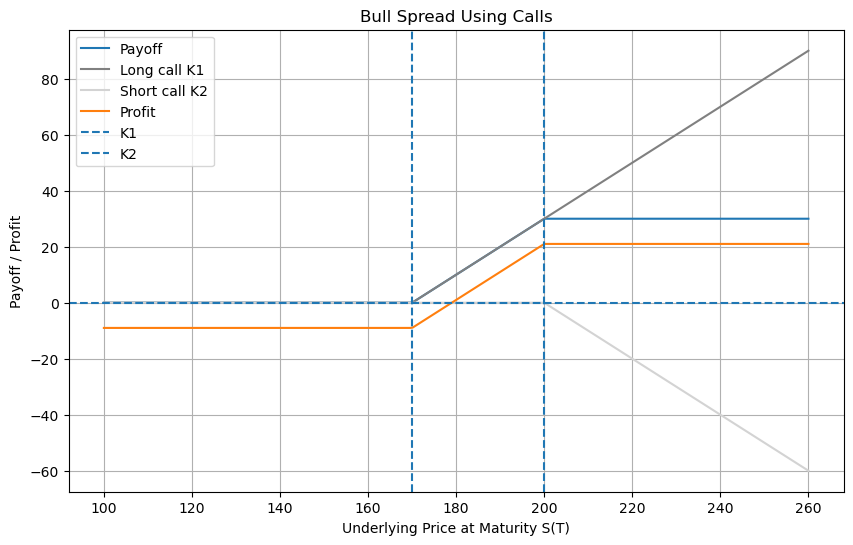

In [15]:
K1 = 170
K2 = 200

premium_call_K1 = 15
premium_call_K2 = 6

long_call_K1 = np.maximum(S_T - K1, 0)
short_call_K2 = -np.maximum(S_T - K2, 0)

bull_spread_payoff = long_call_K1 + short_call_K2
bull_spread_profit = bull_spread_payoff - premium_call_K1 + premium_call_K2

plt.figure(figsize=(10, 6))
plt.plot(S_T, bull_spread_payoff, label="Payoff")
plt.plot(S_T, long_call_K1, label="Long call K1", color='gray')
plt.plot(S_T, short_call_K2, label="Short call K2", color='lightgray')
plt.plot(S_T, bull_spread_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--", label="K1")
plt.axvline(K2, linestyle="--", label="K2")
plt.title("Bull Spread Using Calls")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The bull spread profits when the underlying price increases.

However, the profit is capped because we sold the higher strike call.

The maximum payoff is:

K2 - K1

The initial net cost is:

premium_call_K1 - premium_call_K2

The break-even point is:

K1 + net cost

## Bear Spread Using Puts

A bear spread is used when we expect the underlying price to decrease.

It can be built by:

- buying a put with higher strike K2
- selling a put with lower strike K1

where K1 < K2.

The strategy has limited profit and limited loss.

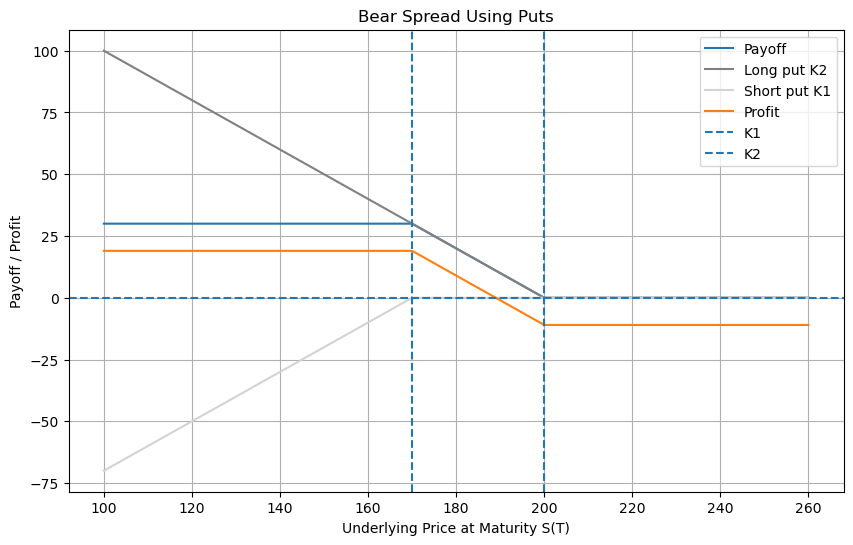

In [16]:
K1 = 170
K2 = 200

premium_put_K1 = 7
premium_put_K2 = 18

long_put_K2 = np.maximum(K2 - S_T, 0)
short_put_K1 = -np.maximum(K1 - S_T, 0)

bear_spread_payoff = long_put_K2 + short_put_K1
bear_spread_profit = bear_spread_payoff - premium_put_K2 + premium_put_K1

plt.figure(figsize=(10, 6))
plt.plot(S_T, bear_spread_payoff, label="Payoff")
plt.plot(S_T, long_put_K2, label="Long put K2", color='gray')
plt.plot(S_T, short_put_K1, label="Short put K1", color='lightgray')
plt.plot(S_T, bear_spread_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--", label="K1")
plt.axvline(K2, linestyle="--", label="K2")
plt.title("Bear Spread Using Puts")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The bear spread profits when the underlying price decreases.

The maximum payoff is reached when the underlying ends below K1.

The profit is capped because we sold the lower strike put.

The maximum payoff is:

K2 - K1

The initial net cost is:

premium_put_K2 - premium_put_K1

The break-even point is:

K2 - net cost

## Butterfly Spread Using Calls

A butterfly spread is used when we expect the underlying price to stay close to a central strike.

It can be built by:

- buying 1 call with strike K1
- selling 2 calls with strike K2
- buying 1 call with strike K3

where K1 < K2 < K3 and K2 is usually the midpoint.

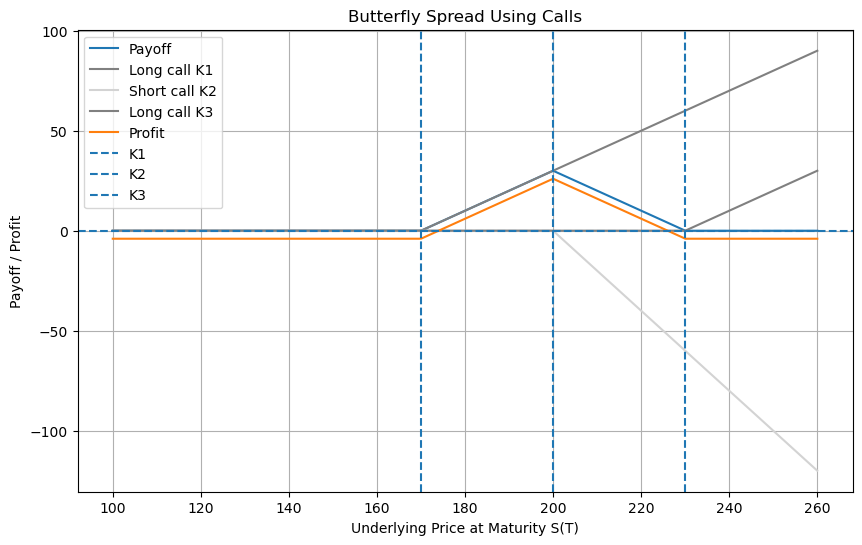

In [20]:
K1 = 170
K2 = 200
K3 = 230

premium_call_K1 = 15
premium_call_K2 = 18
premium_call_K3 = 25

short_call_K2 = -2*np.maximum(S_T - K2, 0)
long_call_K1 = np.maximum(S_T - K1, 0)
long_call_K3 = np.maximum(S_T - K3, 0)

butterfly_spread_payoff = long_call_K1 + short_call_K2 + long_call_K3
butterfly_spread_profit = butterfly_spread_payoff - premium_call_K1 + 2*premium_call_K2 - premium_call_K3

plt.figure(figsize=(10, 6))
plt.plot(S_T, butterfly_spread_payoff, label="Payoff")
plt.plot(S_T, long_call_K1, label="Long call K1", color='gray')
plt.plot(S_T, short_call_K2, label="Short call K2", color='lightgray')
plt.plot(S_T, long_call_K3, label="Long call K3", color='gray')
plt.plot(S_T, butterfly_spread_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K1, linestyle="--", label="K1")
plt.axvline(K2, linestyle="--", label="K2")
plt.axvline(K3, linestyle="--", label="K3")
plt.title("Butterfly Spread Using Calls")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The butterfly spread profits when the underlying price ends close to K2.

It loses money if the price moves too far away from K2.

This is a low-volatility strategy.

Both gains and losses are limited.

## Long Straddle

A long straddle is used when we expect high volatility.

It can be built by:

- buying 1 call
- buying 1 put

with the same strike and maturity.

The investor profits if the underlying moves strongly up or down.

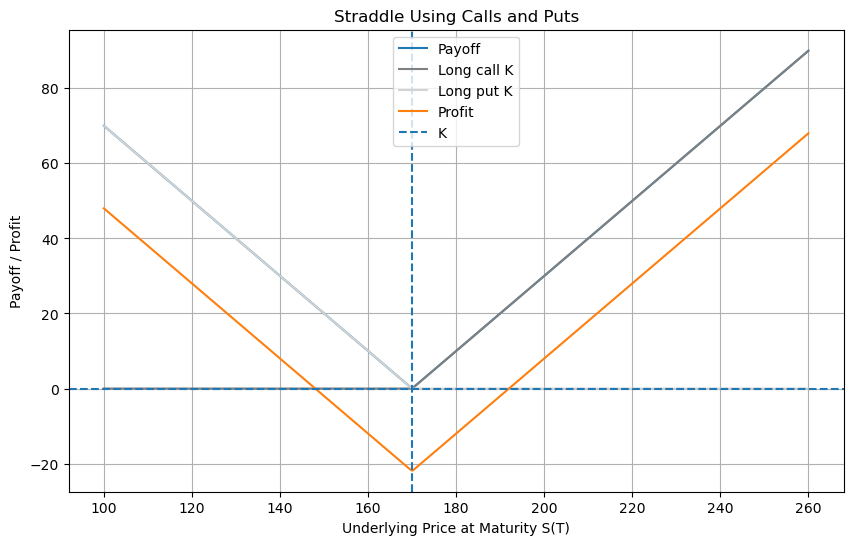

In [21]:
K = 170

premium_call_K = 12
premium_put_K = 10

long_call_K = np.maximum(S_T - K, 0)
long_put_K = np.maximum(K - S_T, 0)

straddle_payoff = long_call_K + long_put_K
straddle_profit = straddle_payoff - premium_call_K - premium_put_K

plt.figure(figsize=(10, 6))
plt.plot(S_T, straddle_payoff, label="Payoff")
plt.plot(S_T, long_call_K, label="Long call K", color='gray')
plt.plot(S_T, long_put_K, label="Long put K", color='lightgray')
plt.plot(S_T, straddle_profit, label="Profit")
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--", label="K")
plt.title("Straddle Using Calls and Puts")
plt.xlabel("Underlying Price at Maturity S(T)")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()